### Verify Image & Label Counts Using Code

In [1]:
import os

BASE_PATH = "../data/yolo_dataset"

def count_files(folder):
    return len(os.listdir(folder))

splits = ["train", "val", "test"]

for split in splits:
    img_path = os.path.join(BASE_PATH, "images", split)
    label_path = os.path.join(BASE_PATH, "labels", split)
    
    img_count = count_files(img_path)
    label_count = count_files(label_path)
    
    print(f"{split.upper()} SET")
    print(f"Images: {img_count}")
    print(f"Labels: {label_count}")
    print("-" * 30)

TRAIN SET
Images: 1509
Labels: 1509
------------------------------
VAL SET
Images: 431
Labels: 431
------------------------------
TEST SET
Images: 217
Labels: 217
------------------------------


### Bounding Box Distribution Analysis

In [2]:
import os
import matplotlib.pyplot as plt

BASE_PATH = "../data/yolo_dataset"
LABEL_PATH = os.path.join(BASE_PATH, "labels")

widths = []
heights = []

for split in ["train", "val", "test"]:
    split_path = os.path.join(LABEL_PATH, split)
    
    for file in os.listdir(split_path):
        file_path = os.path.join(split_path, file)
        
        with open(file_path, "r") as f:
            lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, x, y, w, h = parts
                    widths.append(float(w))
                    heights.append(float(h))

print("Total bounding boxes found:", len(widths))

Total bounding boxes found: 3627


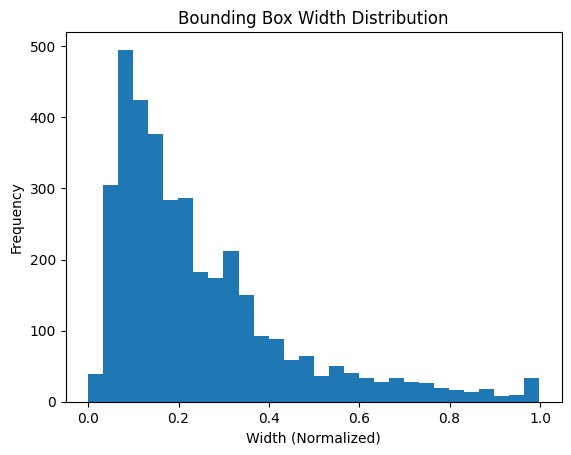

In [3]:
plt.figure()
plt.hist(widths, bins=30)
plt.title("Bounding Box Width Distribution")
plt.xlabel("Width (Normalized)")
plt.ylabel("Frequency")
plt.show()

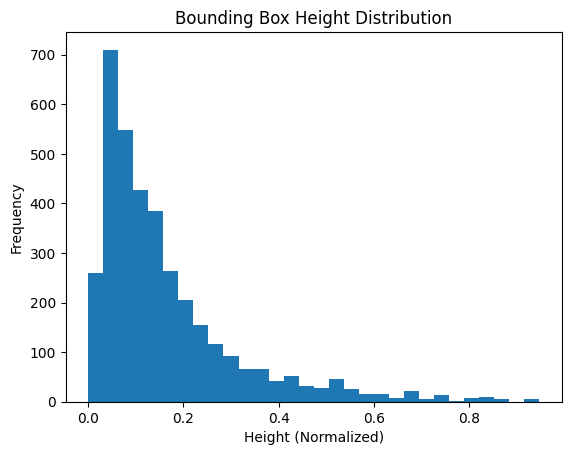

In [4]:
plt.figure()
plt.hist(heights, bins=30)
plt.title("Bounding Box Height Distribution")
plt.xlabel("Height (Normalized)")
plt.ylabel("Frequency")
plt.show()

### Visualize Bounding Box on Image

In [5]:
# import os

# images_path = "../data/yolo_dataset/images/train"
# labels_path = "../data/yolo_dataset/labels/train"

# print("Images exists:", os.path.exists(images_path))
# print("Labels exists:", os.path.exists(labels_path))

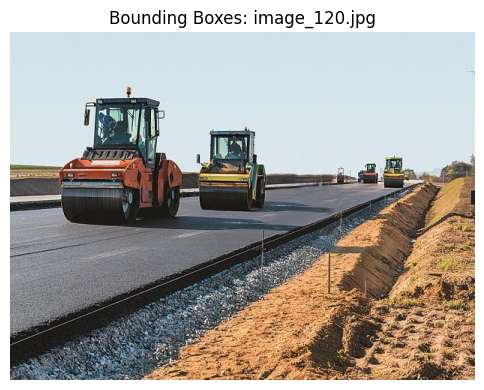

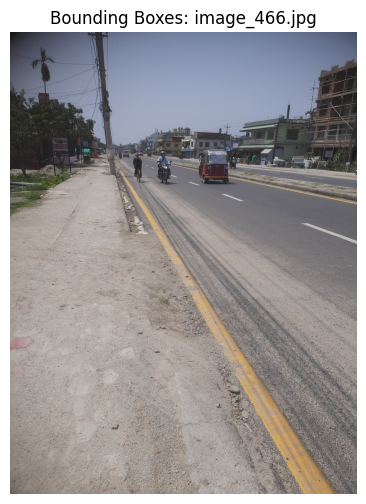

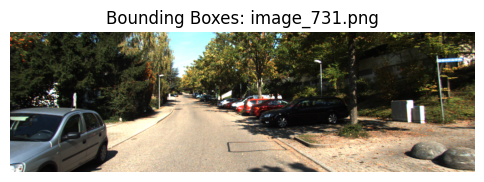

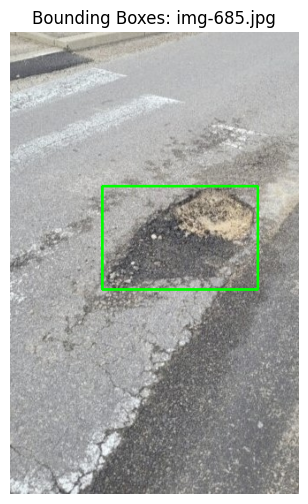

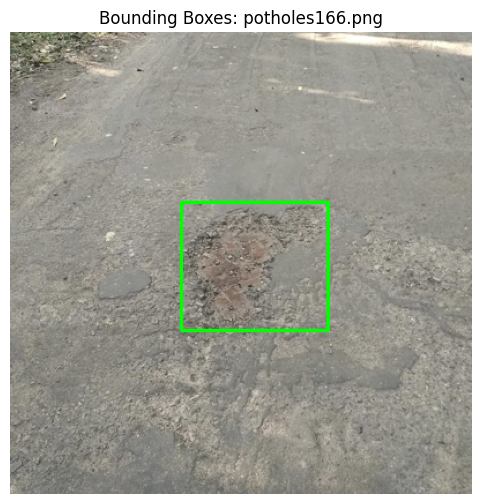

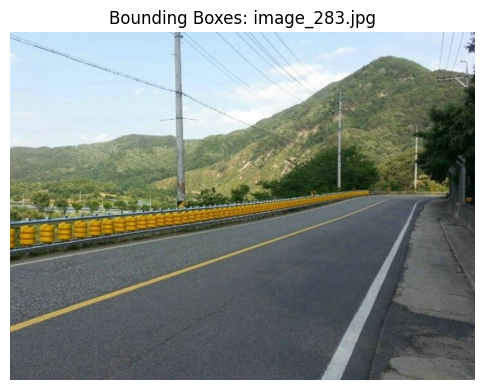

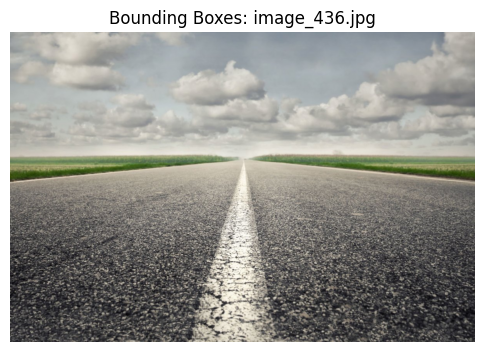

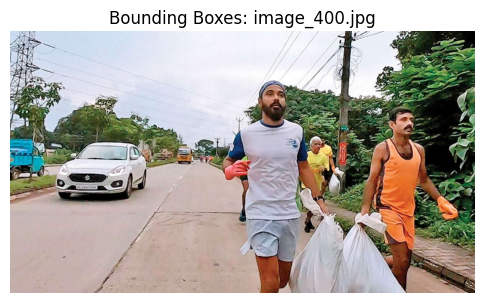

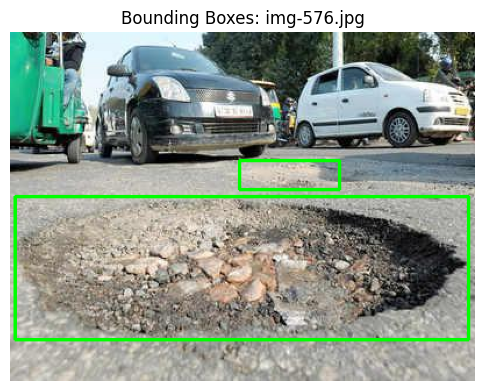

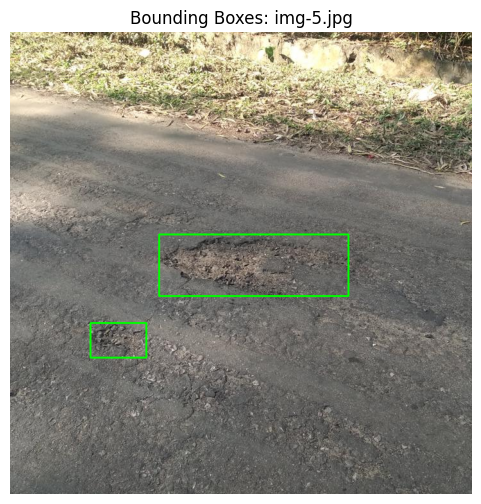

In [6]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Correct paths from your notebook
images_path = "../data/yolo_dataset/images/train"
labels_path = "../data/yolo_dataset/labels/train"

def draw_yolo_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        class_id, x_center, y_center, box_w, box_h = map(float, line.split())

        # Convert normalized to pixel values
        x_center *= w
        y_center *= h
        box_w *= w
        box_h *= h

        x1 = int(x_center - box_w / 2)
        y1 = int(y_center - box_h / 2)
        x2 = int(x_center + box_w / 2)
        y2 = int(y_center + box_h / 2)

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return img


# -------- Show Random Pothole Images --------
image_files = os.listdir(images_path)

shown = 0
while shown < 10:  # show 5 images
    file = random.choice(image_files)
    label_file = file.replace(".jpg", ".txt").replace(".png", ".txt")

    label_path = os.path.join(labels_path, label_file)

    # Skip images without labels (normal images)
    if not os.path.exists(label_path):
        continue

    img_path = os.path.join(images_path, file)
    output_img = draw_yolo_boxes(img_path, label_path)

    plt.figure(figsize=(6,6))
    plt.imshow(output_img)
    plt.axis("off")
    plt.title(f"Bounding Boxes: {file}")
    plt.show()

    shown += 1

### Dataset Summary & Sanity Check

In [7]:
import os

images_path = "../data/yolo_dataset/images/train"
labels_path = "../data/yolo_dataset/labels/train"

image_files = os.listdir(images_path)
label_files = os.listdir(labels_path)

total_images = len(image_files)
total_labels = len(label_files)

# Count pothole images (images having label file)
pothole_images = 0
normal_images = 0

for img in image_files:
    label_name = img.replace(".jpg", ".txt").replace(".png", ".txt")
    if label_name in label_files:
        pothole_images += 1
    else:
        normal_images += 1

print("Total Images:", total_images)
print("Images with Potholes (Labeled):", pothole_images)
print("Normal Images (No Pothole):", normal_images)
print("Total Label Files:", total_labels)

Total Images: 1509
Images with Potholes (Labeled): 1509
Normal Images (No Pothole): 0
Total Label Files: 1509


In [8]:
empty_labels = 0
non_empty_labels = 0

for file in os.listdir(labels_path):
    with open(os.path.join(labels_path, file), "r") as f:
        content = f.read().strip()
        if content == "":
            empty_labels += 1
        else:
            non_empty_labels += 1

print("Non-empty label files (potholes):", non_empty_labels)
print("Empty label files (normal images):", empty_labels)

Non-empty label files (potholes): 966
Empty label files (normal images): 543


### Pothole Density Analysis

Maximum potholes in a single image: 23
Average potholes per image: 1.6368455931080186


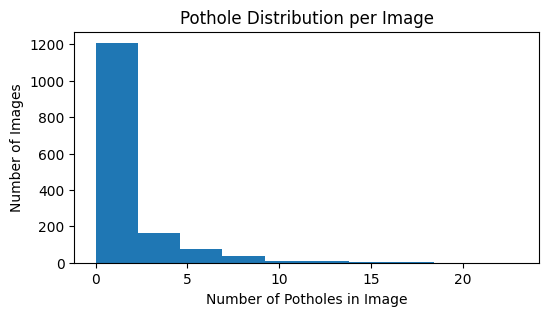

In [10]:
import matplotlib.pyplot as plt

potholes_per_image = []

for file in os.listdir(labels_path):
    with open(os.path.join(labels_path, file), "r") as f:
        lines = f.readlines()
        potholes_per_image.append(len(lines))

print("Maximum potholes in a single image:", max(potholes_per_image))
print("Average potholes per image:", sum(potholes_per_image)/len(potholes_per_image))

plt.figure(figsize=(6,3))
plt.hist(potholes_per_image, bins=10)
plt.xlabel("Number of Potholes in Image")
plt.ylabel("Number of Images")
plt.title("Pothole Distribution per Image")
plt.show()

### Bounding Box Size Analysis

Total Bounding Boxes: 2470
Small Potholes: 1208 (48.91%)
Medium Potholes: 820 (33.20%)
Large Potholes: 442 (17.89%)


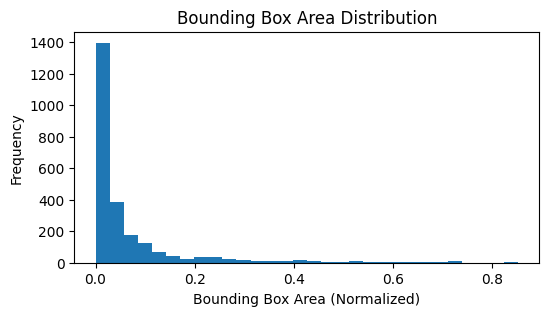

In [12]:
small = 0
medium = 0
large = 0

areas = []

for file in os.listdir(labels_path):
    with open(os.path.join(labels_path, file), "r") as f:
        lines = f.readlines()
        
        for line in lines:
            _, x, y, w, h = map(float, line.split())
            area = w * h
            areas.append(area)
            
            if area < 0.02:
                small += 1
            elif area < 0.10:
                medium += 1
            else:
                large += 1

total_boxes = len(areas)

print("Total Bounding Boxes:", total_boxes)
print("Small Potholes:", small, f"({small/total_boxes*100:.2f}%)")
print("Medium Potholes:", medium, f"({medium/total_boxes*100:.2f}%)")
print("Large Potholes:", large, f"({large/total_boxes*100:.2f}%)")

plt.figure(figsize=(6,3))
plt.hist(areas, bins=30)
plt.xlabel("Bounding Box Area (Normalized)")
plt.ylabel("Frequency")
plt.title("Bounding Box Area Distribution")
plt.show()

### Aspect Ratio Analysis

Average Aspect Ratio: 1.8640172633959635
Min Aspect Ratio: 0.28817064446901214
Max Aspect Ratio: 17.25913998863421


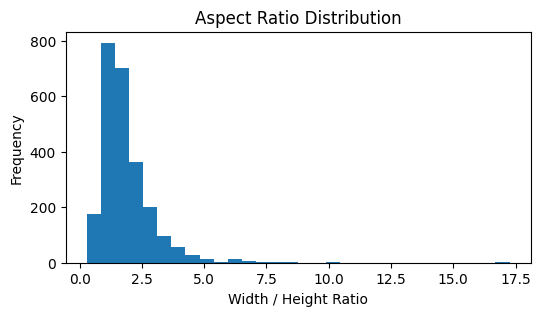

In [14]:
aspect_ratios = []

for file in os.listdir(labels_path):
    with open(os.path.join(labels_path, file), "r") as f:
        lines = f.readlines()
        
        for line in lines:
            _, x, y, w, h = map(float, line.split())
            if h != 0:
                aspect_ratios.append(w / h)

print("Average Aspect Ratio:", sum(aspect_ratios)/len(aspect_ratios))
print("Min Aspect Ratio:", min(aspect_ratios))
print("Max Aspect Ratio:", max(aspect_ratios))

plt.figure(figsize=(6,3))
plt.hist(aspect_ratios, bins=30)
plt.xlabel("Width / Height Ratio")
plt.ylabel("Frequency")
plt.title("Aspect Ratio Distribution")
plt.show()

### Outlier Detection

In [15]:
extreme_boxes = 0

for ratio in aspect_ratios:
    if ratio > 5 or ratio < 0.3:
        extreme_boxes += 1

print("Extreme Aspect Ratio Boxes:", extreme_boxes)
print("Percentage of Extreme Boxes:",
      f"{extreme_boxes/len(aspect_ratios)*100:.2f}%")

Extreme Aspect Ratio Boxes: 51
Percentage of Extreme Boxes: 2.07%


### Dataset Validation Summary

After performing detailed dataset analysis, we conclude:

- Total Training Images: 1509
- Pothole Images: 966
- Normal Images: 543
- Total Bounding Boxes: 2470

### Key Observations:

1. Class distribution is balanced (≈64% pothole, 36% normal).
2. Bounding box sizes are well distributed:
   - Small: 48.9%
   - Medium: 33.2%
   - Large: 17.9%
3. Average potholes per image is moderate, indicating realistic scene complexity.
4. Aspect ratio average ≈ 1.86 (wider than tall potholes).
5. Extreme bounding box outliers are minimal (2.07%).

### Conclusion:

The dataset is clean, well-annotated, and suitable for YOLO-based object detection training.